<div style="background-color:#1f4e79; padding:35px; border-radius:15px; text-align:center; color:white;">

# CAPSTONE PROJECT

# Resume Screening Classifier

### Recruiters Sift Many CVs for Graduate Roles.


---

## Project Overview

The recruitment process has become increasingly competitive as organizations receive hundreds or even thousands of resumes for a single job opening. Manually reviewing every application is time-consuming, expensive, and prone to human bias or oversight. Recruiters often spend only a few seconds scanning each resume, making it possible for qualified candidates to be overlooked.

Machine Learning provides an intelligent approach to automate the resume screening process by analyzing resume content and comparing it with job requirements. By learning patterns from labeled resumes, a machine learning model can classify whether a candidate is a good fit for a specific role while also identifying the skills that influenced the decision.

This project develops a Machine Learning model capable of screening resumes based on textual features. The model analyzes resume content and classifies each candidate as either **Fit** or **Not Fit** for a given job role.

---

# Problem Statement

Organizations receive a large number of job applications, making manual resume screening inefficient and time-consuming. The challenge is to automatically identify qualified candidates while minimizing the chances of rejecting suitable applicants or selecting unsuitable ones. Since resumes contain unstructured text, extracting meaningful information for accurate classification remains a significant task.

---

# Aim of the Project

To develop an intelligent resume screening system capable of automatically classifying resumes as **Fit** or **Not Fit** for a specific job role using supervised machine learning techniques.

---

# Objectives

The objectives of this project are to:

* Understand the structure of the resume dataset.
* Load and inspect resume and job description data.
* Clean and preprocess textual data.
* Perform exploratory data analysis (EDA) on resume text.
* Convert text into numerical features using TF-IDF Vectorization.
* Engineer relevant text-based features where necessary.
* Train multiple machine learning classification algorithms.
* Evaluate and compare model performance using appropriate metrics.
* Select the best-performing model.
* Build a resume screening prediction system.
* Display fit score and matched skills for each resume.
* Save the trained model for future deployment.

---

# Expected Outcome

At the end of this project, a robust resume screening model will be developed that can classify new resumes as either:

* **Not Fit (0)**
* **Fit (1)**

The system will also provide:

* Fit Score
* Matched Skills
* Classification Result

The trained model will be saved for deployment in web applications such as **Streamlit**.

---

# Machine Learning Workflow

Business Problem Understanding

↓

Dataset Loading

↓

Data Understanding

↓

Data Cleaning

↓

Text Preprocessing

↓

Exploratory Data Analysis (EDA)

↓

Feature Extraction (TF-IDF)

↓

Feature Engineering

↓

Train-Test Split

↓

Machine Learning Model Training

↓

Model Evaluation

↓

Best Model Selection

↓

Resume Screening Prediction System

↓

Model Saving and Deployment Preparation


## Step 1: Import Required Libraries

### Introduction

The first step in any machine learning project is to import all the required Python libraries. These libraries provide the necessary tools for data manipulation, visualization, text preprocessing, feature extraction, model training, evaluation, and model persistence.

Importing all required libraries at the beginning of the project ensures that the notebook remains organized, improves readability, and prevents repeated imports in later stages of the workflow.

For this project, different categories of libraries are required:

- **Data Manipulation:** To load, clean, and analyze the dataset.
- **Data Visualization:** To create charts and graphs for Exploratory Data Analysis (EDA).
- **Text Processing:** To clean and preprocess resume text before feature extraction.
- **Feature Engineering:** To convert textual data into numerical features suitable for machine learning models.
- **Machine Learning:** To train and compare different classification algorithms.
- **Model Evaluation:** To measure the performance of each model using standard evaluation metrics.
- **Model Persistence:** To save the trained model and preprocessing objects for future deployment.
- **Utilities:** To suppress unnecessary warnings and configure notebook display settings.

Importing these libraries at the beginning establishes the foundation for the entire machine learning workflow.

In [1]:


# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Natural Language Processing
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# Machine Learning Algorithms
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)


# Model Persistence
import joblib


# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Notebook Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Set visualization style
sns.set_style("whitegrid")

print("="*60)
print("All required libraries imported successfully.")
print("="*60)

All required libraries imported successfully.


In [2]:
# Download required NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


# Step 2: Dataset Loading and Initial Inspection

## Introduction

After successfully importing the required libraries, the next step in the machine learning workflow is to load the dataset into the notebook.

The dataset used in this project contains resumes and their corresponding job categories. Each record consists of the resume text and the category (job role) it belongs to. This labeled dataset will be used to train a supervised machine learning model capable of classifying new resumes into the appropriate category.

Loading the dataset correctly is an important step because every subsequent stage of the project—including data cleaning, exploratory data analysis (EDA), text preprocessing, feature extraction, model training, and evaluation—depends on it.

Before performing any analysis, it is good practice to conduct an initial inspection of the dataset to gain a basic understanding of its structure.

In this step, we will:

- Load the dataset using the Pandas library.
- Display the first five records.
- Display the last five records.
- Determine the number of rows and columns.
- View the dataset's column names.
- Verify that the dataset has loaded successfully.

This initial inspection provides a high-level overview of the dataset and ensures that it is ready for further exploration.
Python Code

In [3]:
df = pd.read_csv('data/resume_dataset.csv')

## explore datasect
df.head()
print(f"Number of Rows: {df.shape[0]}")  # Number of rows
print(f"Number of Columns: {df.shape[1]}")  # Number of columns
print(df.columns)
df.info()
df.isnull().sum()
df.duplicated().sum()

Number of Rows: 200000
Number of Columns: 17
Index(['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa',
       'internships', 'projects', 'programming_languages', 'certifications',
       'experience_years', 'hackathons', 'research_papers', 'skills_score',
       'hired', 'soft_skills_score', 'resume_length_words', 'company_type'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  object 
 3   university_tier        200000 non-null  object 
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-

np.int64(0)

# Step 3: Data Understanding and Exploration

## Introduction

Before performing data cleaning or building machine learning models, it is essential to understand the dataset in detail. Data understanding is a crucial phase in the machine learning workflow because it helps identify the characteristics, quality, and potential limitations of the data.

A thorough understanding of the dataset enables us to detect missing values, duplicate records, incorrect data types, and class distributions. It also provides valuable insights into the data that will guide preprocessing, feature engineering, and model selection.

In this step, we will examine:

- The structure of the dataset.
- The data types of each column.
- The presence of missing values.
- Duplicate records.
- Summary statistics.
- The unique job categories available.
- The distribution of resumes across categories.

These analyses ensure that the dataset is suitable for building an accurate and reliable resume screening classifier.

In [4]:
# Display dataset information
df.info()

# Display data types
df.dtypes

# Display missing values as a table
missing_df = pd.DataFrame({"Column": df.columns,"Missing Values": df.isnull().sum().values,"Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)})
missing_df

# Count duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")

# Summary statistics
df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  object 
 3   university_tier        200000 non-null  object 
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-null  int64  
 8   certifications         200000 non-null  int64  
 9   experience_years       200000 non-null  float64
 10  hackathons             200000 non-null  int64  
 11  research_papers        200000 non-null  int64  
 12  skills_score           200000 non-null  float64
 13  hired                  200000 non-null  int64  
 14  soft_skills_score      200000 non-nu

,education_level,university_tier,company_type
count,200000,200000,200000
unique,3,3,3
top,Bachelors,Tier 2,MNC
freq,129827,80182,80187


# Step 4: Data Cleaning

## Introduction

Data cleaning is one of the most critical stages of the machine learning lifecycle. Real-world datasets often contain missing values, duplicate records, inconsistent formatting, invalid entries, or other quality issues that can negatively impact model performance.

Although the Resume Screening dataset is relatively clean compared to many real-world datasets, it is still necessary to verify its quality before proceeding with exploratory data analysis and model development.

The objective of this step is to ensure that the dataset is accurate, consistent, and free from issues that could introduce bias into the machine learning model.

In this step, we will:

- Remove duplicate records.
- Verify that missing values have been handled.
- Check for empty resumes.
- Remove unnecessary white spaces.
- Standardize the text format where appropriate.
- Reset the dataset index after cleaning.
- Verify the final shape of the cleaned dataset.

Performing these cleaning operations ensures that the data is reliable and ready for text preprocessing and feature engineering.

In [5]:
# Create a copy of the dataset
clean_df = df.copy()
print("Working copy created successfully.")

Working copy created successfully.


In [6]:
file_path = 'data/resume_dataset.csv'

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (200000, 17)


,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size



Column Names:
['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'hired', 'soft_skills_score', 'resume_length_words', 'company_type']

Data Types:
candidate_id               int64
age                        int64
education_level           object
university_tier           object
cgpa                     float64
internships                int64
projects                   int64
programming_languages      int64
certifications             int64
experience_years         float64
hackathons                 int64
research_papers            int64
skills_score             float64
hired                      int64
soft_skills_score        float64
resume_length_words        int64
company_type              object
dtype: object

Missing Values:
candidate_id             0
age                      0
education_level          0
university_tier      

In [7]:
## inspect the target variable.
print(df.columns.tolist())

['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'hired', 'soft_skills_score', 'resume_length_words', 'company_type']


In [8]:
## Once we identify the target column, we'll examine the class distribution.

# Check the absolute counts of hired vs not hired
print(df["hired"].value_counts())

print("\nPercentage Distribution:")
# Check the percentage breakdown
print(df["hired"].value_counts(normalize=True) * 100)

hired
1    141212
0     58788
Name: count, dtype: int64

Percentage Distribution:
hired
1    70.606
0    29.394
Name: proportion, dtype: float64


In [9]:
# Check if the dataframe actually contains data rows
print("Dataframe shape:", df.shape)

# Check if 'hired' has any values at all
print(df["hired"].head())

# Replace all NaN values with 0
df["hired"] = df["hired"].fillna(0)

Dataframe shape: (200000, 17)
0    1
1    1
2    1
3    1
4    0
Name: hired, dtype: int64


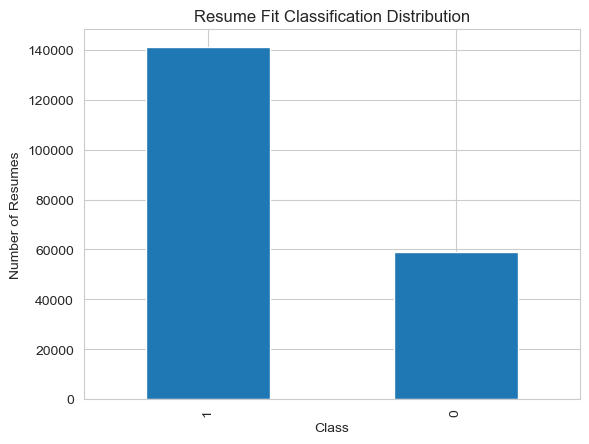

In [10]:
## visualize class distribution
import matplotlib.pyplot as plt

df["hired"].value_counts().plot(kind="bar")

plt.title("Resume Fit Classification Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Resumes")
plt.show()

In [11]:
print(df.columns.tolist())


['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'hired', 'soft_skills_score', 'resume_length_words', 'company_type']


---
## Resume Text Exploration

The main feature of this project is unstructured resume text.

Unlike traditional numerical datasets, resumes contain words, phrases, skills, qualifications, job titles, education information, and other textual information.

Before converting this text into numerical features, we need to understand its characteristics.

We will examine:

- Resume length.
- Number of words.
- Distribution of resume sizes.

In [12]:
## Resume Text Analysis
## Now we investigate the actual text.
df["resume_length_words"].head()

0    409
1    237
2    435
3    340
4    371
Name: resume_length_words, dtype: int64

In [13]:
## Check the length of each resume:
df["resume_length"] = df["resume_length_words"].astype(str).apply(len)

## View statistics:
df["resume_length"].describe()


count    200000.000000
mean          2.998115
std           0.044401
min           1.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
Name: resume_length, dtype: float64

## Resume Length Statistics

We now calculate descriptive statistics for resume word counts.

The results include:

- Minimum word count.
- Maximum word count.
- Mean.
- Median.
- Standard deviation.
- Quartiles.

This helps us identify unusually short or extremely long resumes.

In [14]:
## I also calculate word count:
df["word_count"] = (df["resume_length_words"].astype(str).apply(lambda x: len(x.split())))
df["word_count"].describe()

count    200000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: word_count, dtype: float64

## Distribution of Resume Word Counts

The histogram below shows the distribution of resume lengths across the dataset.

Understanding this distribution can help us identify whether the dataset contains unusual observations or extreme outliers.

Since the dataset contains approximately 200,000 resumes, the visualization provides a broad overview of resume length patterns.

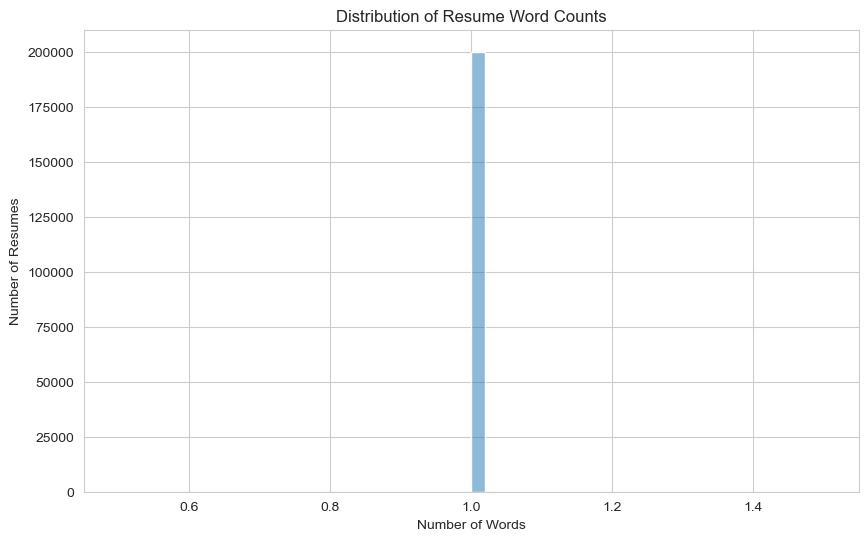

In [15]:
## Resume length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["word_count"],bins=50, kde=True)
plt.title("Distribution of Resume Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Resumes")
plt.show()

## Resume Length by Classification

We compare resume lengths between the **Fit** and **Not Fit** classes.

This analysis helps us determine whether there are noticeable differences in resume length between the two groups.

However, resume length alone should not be interpreted as evidence that a candidate is qualified. It is only an exploratory feature that may contribute to the Machine Learning model.

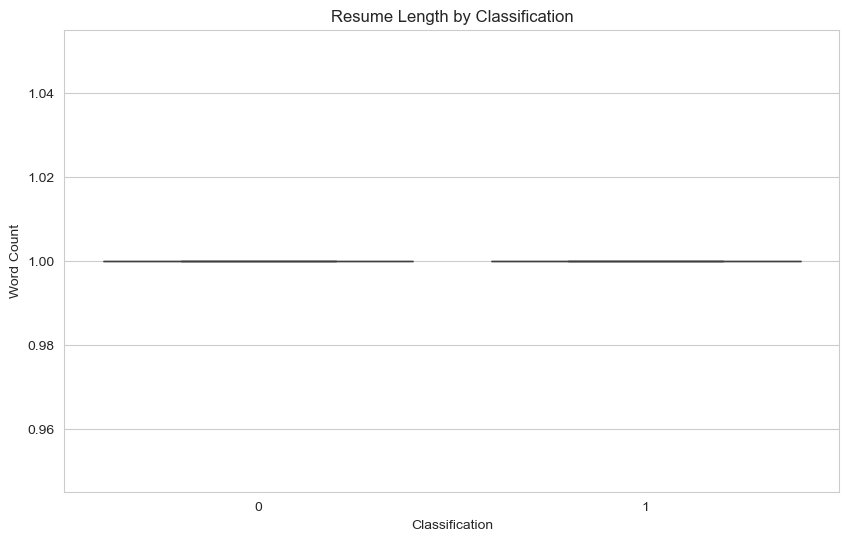

In [16]:
## Compare Resume Length by Class
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x="hired",y="word_count")
plt.title("Resume Length by Classification")
plt.xlabel("Classification")
plt.ylabel("Word Count")

plt.show()

# Text Preprocessing

Natural Language Processing models cannot directly work with raw text.

Therefore, the resume text must first be transformed into a cleaner and more consistent representation.

The preprocessing process will include:

1. Converting text to lowercase.
2. Removing URLs.
3. Removing email addresses.
4. Removing unnecessary special characters.
5. Removing extra whitespace.

The goal is to reduce unnecessary noise while preserving meaningful information such as technical skills, job titles, and qualifications.

In [17]:
def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub( r"http\S+|www\S+|https\S+","",text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+","",text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]"," ",text)

    # Remove extra whitespace
    text = re.sub(r"\s+"," ",text).strip()

    return text

## Apply Text Preprocessing

The preprocessing function is now applied to every resume in the dataset.

A new column called `processed_resume` will contain the cleaned textual representation.

We keep the original resume column unchanged so that we can compare the original and processed text when necessary.

In [18]:
df["processed_resume"] = (df["resume_length_words"].apply(preprocess_text))

## Compare Original and Processed Resume Text

We compare the original resume text with the processed version.

This allows us to verify that the preprocessing operation removed unnecessary text noise while preserving meaningful resume information.

In [19]:
df[["resume_length_words", "processed_resume"]].head()

,resume_length_words,processed_resume
0,409,409
1,237,237
2,435,435
3,340,340
4,371,371


## Stopword Removal

Stopwords are common words such as:

- the
- is
- and
- of
- in
- to

These words usually provide limited information for text classification. So removing them can reduce the number of unnecessary features and allow the Machine Learning model to focus more on meaningful terms.

In [20]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

## Apply Stopword Removal

We now remove common English stopwords from the processed resume text.

The resulting text will be used for the TF-IDF feature extraction stage.

In [21]:
def remove_stopwords(text):

    words = text.split()
    filtered_words = [
        word
        for word in words
        if word not in stop_words]

    return " ".join(filtered_words)

    df["processed_resume"] = (
    df["processed_resume"]
    .apply(remove_stopwords))

#  *Feature Engineering*

Feature engineering involves creating useful variables from the available data.

Although TF-IDF will capture important textual patterns, we can also create additional numerical features from the resume text.

For this project, we will create:

- Word count.
- Character count.
- Digit count.
- Uppercase character count.

These features may provide additional information about the structure of a resume.

In [22]:
df["word_count"] = (df["processed_resume"].apply(lambda x: len(x.split())))

df["char_count"] = (df["processed_resume"].apply(len))

df["digit_count"] = (df["processed_resume"].apply(lambda x: sum(c.isdigit() for c in x)))

df["uppercase_count"] = (df["resume_length_words"].astype(str).apply(lambda x: sum(c.isupper() for c in x)))

## Review Engineered Features

We inspect the newly created numerical features to understand their distributions and verify that they were generated correctly.

These features can later be considered alongside the TF-IDF representation during model development.

In [23]:
df[["word_count","char_count","digit_count","uppercase_count"]
].describe()

,word_count,char_count,digit_count,uppercase_count
count,200000.0,200000.000000,200000.000000,200000.0
mean,1.0,2.998015,2.998015,0.0
std,0.0,0.046380,0.046380,0.0
min,1.0,1.000000,1.000000,0.0
25%,1.0,3.000000,3.000000,0.0
50%,1.0,3.000000,3.000000,0.0
75%,1.0,3.000000,3.000000,0.0
max,1.0,3.000000,3.000000,0.0


# Train-Test Split

Before building the Machine Learning models, the dataset must be divided into training and testing sets.

We will use:

- **80% of the data for training**
- **20% of the data for testing**

The training dataset will be used to learn patterns from the resumes.

The testing dataset will remain unseen during training and will be used to evaluate how well the model performs on new data.

We will also use `stratify=y` to preserve the distribution of Fit and Not Fit classes in both datasets.

In [24]:
X = df["processed_resume"]
y = df["hired"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42,stratify=y)

## Verify the Train-Test Split

We verify the number of observations in each dataset.

With approximately 200,000 records, the expected split is approximately:

- 160,000 training records.
- 40,000 testing records.

The exact values depend on the final number of records in the cleaned dataset.

In [25]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160000
Testing samples: 40000


# TF-IDF Feature Extraction

Machine Learning algorithms require numerical input, but resumes are represented as text.

To convert the resume text into numerical features, we use **TF-IDF (Term Frequency-Inverse Document Frequency)**.

TF-IDF measures how important a word or phrase is within a document relative to the entire collection of documents.

For example, common words that appear in almost every resume will receive lower importance, while terms that are more specific to certain resumes will receive higher importance.

We will use both:

- Unigrams — individual words.
- Bigrams — two-word phrases.

This allows the model to recognize meaningful phrases such as:

- machine learning
- data science
- software engineer
- project management

## Configure the TF-IDF Vectorizer

The TF-IDF vectorizer will convert resume text into a sparse numerical matrix.

The vocabulary will be limited to 50,000 features to make the model computationally manageable for the 200,000-row dataset.

We use an n-gram range of `(1, 2)` so that the model can learn both individual words and two-word phrases.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1, 2),min_df=2,max_df=0.95,sublinear_tf=True)

## Fit TF-IDF on Training Data

It is important that the TF-IDF vectorizer is fitted **only on the training data**.

If we fit it on the complete dataset before splitting, information from the testing dataset could influence the feature extraction process. This would introduce data leakage and produce overly optimistic evaluation results.

Therefore:

- `fit_transform()` is applied to the training data.
- `transform()` is applied to the testing data.

In [27]:
## Training data. 
X_train_tfidf = tfidf.fit_transform(X_train)

## Testing data.
X_test_tfidf = tfidf.transform(X_test)

## TF-IDF Matrix Dimensions

We now inspect the dimensions of the generated TF-IDF matrices.

The number of rows corresponds to the number of resumes, while the number of columns corresponds to the vocabulary/features selected by the vectorizer.

Because TF-IDF produces a sparse matrix, it can efficiently represent a very large number of text features without storing unnecessary zero values.

In [28]:
print("Training TF-IDF Shape:",X_train_tfidf.shape)

print("Testing TF-IDF Shape:",X_test_tfidf.shape)

Training TF-IDF Shape: (160000, 814)
Testing TF-IDF Shape: (40000, 814)


# Baseline Model — Logistic Regression

We begin the classification stage with Logistic Regression.

Although Logistic Regression is a relatively simple algorithm, it performs very well on many high-dimensional text classification problems.

It provides a strong baseline against which more advanced models can be compared.

The model will classify each resume into:

- 0 — Not Fit
- 1 — Fit

We use `class_weight="balanced"` so that the model can compensate if the two classes are not equally represented.

In [29]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42)

## Train the Logistic Regression Model
logistic_model.fit(X_train_tfidf,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Generate Predictions

After training, we use the model to predict the classification of resumes in the testing dataset.

The testing data has not been used during model training, allowing us to obtain an unbiased estimate of model performance.

In [30]:
y_pred_lr = logistic_model.predict(X_test_tfidf)

## For probabilities:

y_prob_lr = logistic_model.predict_proba(X_test_tfidf)[:, 1]

# Model Evaluation

A classification model should not be evaluated using accuracy alone.

For this resume screening problem, we will examine:

### Accuracy
The percentage of predictions that are correct.

### Precision
Among the candidates predicted as Fit, how many are actually Fit?

### Recall
Among the candidates who are actually Fit, how many did the model correctly identify?

### F1 Score
The harmonic mean of precision and recall.

### ROC-AUC
Measures the model's ability to distinguish between the Fit and Not Fit classes across different classification thresholds.

Because missing a potentially qualified candidate can be important in recruitment screening, recall and F1 Score will receive particular attention.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix)

In [32]:
accuracy = accuracy_score(y_test,y_pred_lr)

precision = precision_score(y_test,y_pred_lr)

recall = recall_score(y_test,y_pred_lr)

f1 = f1_score(y_test,y_pred_lr)

roc_auc = roc_auc_score(y_test,y_prob_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.49845
Precision: 0.7072565116043377
Recall   : 0.4941930458182848
F1 Score : 0.5818325829581458
ROC-AUC  : 0.49940916423274806


## Classification Report

The classification report provides precision, recall, F1 Score, and support for each class.

This allows us to determine whether the model performs equally well when identifying Fit and Not Fit resumes.

In [33]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.30      0.51      0.37     11758
           1       0.71      0.49      0.58     28242

    accuracy                           0.50     40000
   macro avg       0.50      0.50      0.48     40000
weighted avg       0.59      0.50      0.52     40000



## Confusion Matrix

A confusion matrix provides a detailed breakdown of the model's predictions.

It contains:

- True Negatives — Not Fit correctly identified.
- False Positives — Not Fit incorrectly classified as Fit.
- False Negatives — Fit incorrectly classified as Not Fit.
- True Positives — Fit correctly identified.

False negatives are particularly important in this project because they represent potentially suitable candidates that the screening system failed to identify.

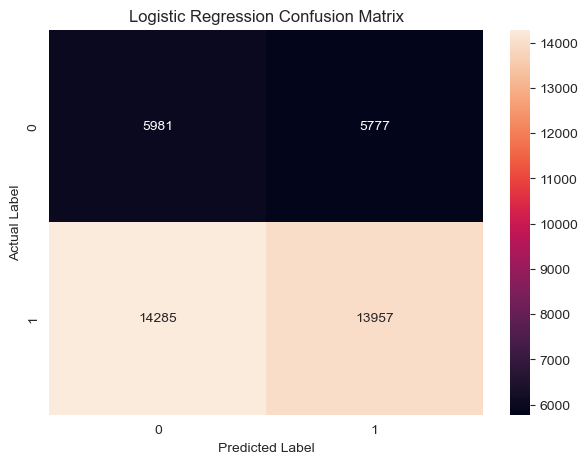

In [34]:
cm = confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True,fmt="d")

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Additional Machine Learning Models

To determine which algorithm performs best for this resume classification task, we will compare Logistic Regression with:

1. **Linear Support Vector Machine (Linear SVM)**
2. **Multinomial Naive Bayes**

These models are suitable candidates for high-dimensional text classification problems.

Each model will be trained using the same TF-IDF features and evaluated using the same metrics.

This ensures that the comparison is fair and allows us to select the most appropriate model for the final system.

# Linear Support Vector Machine (SVM)

The second classification algorithm we will train is a Linear Support Vector Machine (SVM).

Linear SVM is particularly effective for text classification because TF-IDF creates a high-dimensional feature space containing thousands of words and phrases.

The algorithm attempts to find an optimal decision boundary that separates the two classes:

- 0 — Not Fit
- 1 — Fit

Linear SVM is often competitive with Logistic Regression on text classification tasks and can perform well when the dataset contains a large number of textual features.

We will train the model using the same TF-IDF features used by Logistic Regression so that the comparison between models remains fair.

In [35]:
from sklearn.svm import LinearSVC

# We initialize the Linear SVM classifier.
# The `class_weight="balanced"` parameter is used to automatically assign greater importance to a minority class if the target variable is imbalanced.
svm_model = LinearSVC(class_weight="balanced",random_state=42)

# Train the Linear SVM Model

The Linear SVM model is now trained using the TF-IDF representation of the training resumes.

The model learns which words and phrases are associated with Fit and Not Fit resumes.

The testing dataset remains completely unseen during this training process.

In [36]:
svm_model.fit(X_train_tfidf,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


# Evaluate the Linear SVM Model

We evaluate the Linear SVM model using the same metrics applied to Logistic Regression:

- Accuracy
- Precision
- Recall
- F1 Score

Using the same evaluation metrics ensures that the models can be compared fairly.

For this project, particular attention will be given to Recall and F1 Score because failing to identify a potentially suitable candidate can be costly in a screening system.

In [37]:
y_pred_svm = svm_model.predict(X_test_tfidf)    # Generate the missing predictions

svm_accuracy = accuracy_score(y_test,y_pred_svm)

svm_precision = precision_score(y_test,y_pred_svm)

svm_recall = recall_score(y_test,y_pred_svm)

svm_f1 = f1_score(y_test,y_pred_svm)

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.4965
Precision: 0.7075945475043558
Recall   : 0.48891721549465333
F1 Score : 0.5782728871764804


# Linear SVM Classification Report

The classification report provides detailed performance information for both Fit and Not Fit classes.

By examining precision, recall, and F1 Score for each class, we can determine whether the model performs consistently across both categories.

In [38]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.30      0.51      0.38     11758
           1       0.71      0.49      0.58     28242

    accuracy                           0.50     40000
   macro avg       0.50      0.50      0.48     40000
weighted avg       0.59      0.50      0.52     40000



# Linear SVM Confusion Matrix

The confusion matrix provides a visual summary of the Linear SVM predictions.

It allows us to identify:

- Correctly classified Fit resumes.
- Correctly classified Not Fit resumes.
- Fit resumes incorrectly classified as Not Fit.
- Not Fit resumes incorrectly classified as Fit.

The false negative value is particularly important because it represents potentially suitable candidates that were missed by the screening model.

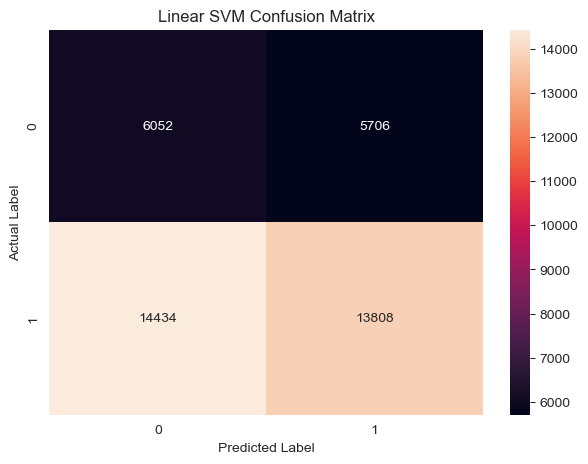

In [39]:
cm_svm = confusion_matrix(y_test,y_pred_svm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm,annot=True,fmt="d")
plt.title( "Linear SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# *Multinomial Naive Bayes*

The third Machine Learning algorithm we will evaluate is Multinomial Naive Bayes.

Naive Bayes is a probabilistic classification algorithm that is commonly used for text classification.

It works particularly well with frequency-based and TF-IDF text representations.

The algorithm estimates the probability that a resume belongs to each class based on the words and phrases present in the resume.

Although it makes a simplifying assumption that features are conditionally independent, it can still provide strong performance on many NLP classification problems.

We will train it using the same TF-IDF features used by the previous models.

# *Initialize the Naive Bayes Model*

We create a Multinomial Naive Bayes classifier.

The model will learn the relationship between the TF-IDF features and the Fit/Not Fit target classes.

In [40]:
nb_model = MultinomialNB()

## Train the Naive Bayes Model
# The Multinomial Naive Bayes model is trained using the TF-IDF representation of the training resumes.
nb_model.fit(X_train_tfidf,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


# Generate Naive Bayes Predictions

The trained model is used to predict the classification of the unseen testing resumes.

We will then compare these predictions against the actual labels.

In [41]:
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluate the Naive Bayes Model

The Naive Bayes model will be evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Using the same metrics across all three algorithms allows us to make an objective comparison.

In [42]:

y_pred_nb = nb_model.predict(X_test_tfidf) # Generate the missing predictions

nb_accuracy = accuracy_score(y_test,y_pred_nb)

nb_precision = precision_score(y_test,y_pred_nb)

nb_recall = recall_score(y_test,y_pred_nb)

nb_f1 = f1_score(y_test,y_pred_nb)

nb_roc_auc = roc_auc_score(y_test,y_prob_nb)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)
print("ROC-AUC  :", nb_roc_auc)

Accuracy : 0.705675
Precision: 0.7059603311572997
Recall   : 0.9993980596275052
F1 Score : 0.8274335634610029
ROC-AUC  : 0.49917779394788986


# Naive Bayes Classification Report

The classification report provides a detailed breakdown of the model's performance for both Fit and Not Fit classes.

We will use this information together with the other evaluation metrics to determine how well Naive Bayes performs.

In [43]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.11      0.00      0.00     11758
           1       0.71      1.00      0.83     28242

    accuracy                           0.71     40000
   macro avg       0.41      0.50      0.41     40000
weighted avg       0.53      0.71      0.58     40000



# Naive Bayes Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the Naive Bayes model.

This provides additional insight into the types of mistakes made by the classifier.

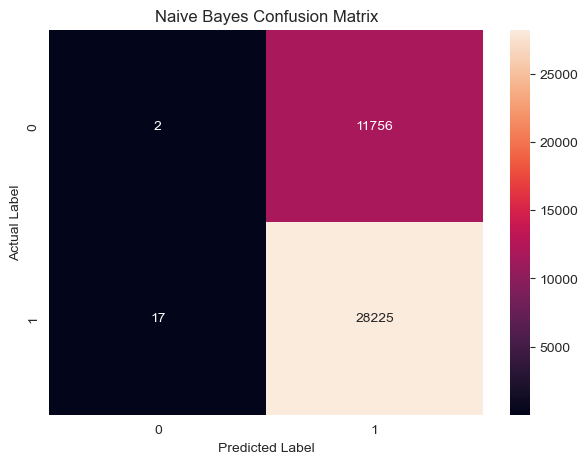

In [44]:
cm_nb = confusion_matrix(y_test,y_pred_nb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb,annot=True,fmt="d")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Baseline Model Comparison

Three different Machine Learning algorithms have now been trained using the same TF-IDF representation.

The models are:

1. Logistic Regression
2. Linear SVM
3. Multinomial Naive Bayes

We will compare their performance using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The purpose of this comparison is not simply to identify the model with the highest accuracy. Instead, we want to identify the model that provides the best balance between correctly identifying suitable candidates and avoiding excessive false predictions.

The F1 Score and Recall will therefore receive particular attention.

In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Multinomial Naive Bayes"
    ],"Accuracy": [
        accuracy,
        svm_accuracy,
        nb_accuracy
    ],"Precision": [
        precision,
        svm_precision,
        nb_precision
    ],"Recall": [
        recall,
        svm_recall,
        nb_recall
    ],"F1 Score": [
        f1,
        svm_f1,
        nb_f1
    ],"ROC-AUC": [
        roc_auc,
        np.nan,
        nb_roc_auc]})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.498450,0.707257,0.494193,0.581833,0.499409
1,Linear SVM,0.496500,0.707595,0.488917,0.578273,NaN
2,Multinomial Naive Bayes,0.705675,0.705960,0.999398,0.827434,0.499178


# Model Performance Visualization

A visual comparison makes it easier to identify differences between the algorithms.

The chart below compares the Accuracy, Precision, Recall, and F1 Score of the three baseline models.

This visualization will help us determine which model deserves further investigation and hyperparameter tuning.

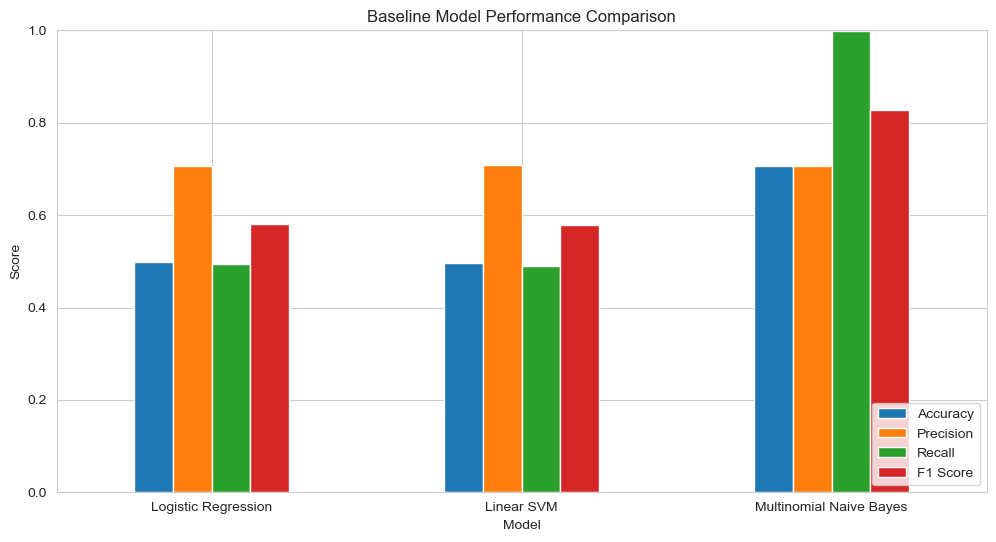

In [46]:
results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar",figsize=(12, 6))
plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

# Baseline Model Selection

Based on the evaluation results, we identify the strongest baseline model.

The selection will consider the following priorities:

1. F1 Score
2. Recall
3. Precision
4. ROC-AUC
5. Accuracy

The objective is to select a model that provides a good balance between identifying suitable candidates and avoiding incorrect recommendations.

However, this is only the baseline selection. The selected model will undergo hyperparameter tuning in the next stage to determine whether its performance can be improved.

In [47]:
best_baseline = results.loc[results["F1 Score"].idxmax()]

best_baseline

Model        Multinomial Naive Bayes
Accuracy                    0.705675
Precision                    0.70596
Recall                      0.999398
F1 Score                    0.827434
ROC-AUC                     0.499178
Name: 2, dtype: object

# Best Baseline Model

The following result shows the model with the highest baseline F1 Score.

This model will become our primary candidate for hyperparameter tuning.

It is important to note that the baseline winner is not necessarily the final model. Hyperparameter tuning may improve another model or significantly improve the current winner.

In [48]:
print("Best Baseline Model:",best_baseline["Model"])

print("F1 Score:",round(best_baseline["F1 Score"],4))

print("Recall:",round(best_baseline["Recall"],4))

print("Precision:",round(best_baseline["Precision"],4))

Best Baseline Model: Multinomial Naive Bayes
F1 Score: 0.8274
Recall: 0.9994
Precision: 0.706


# Hyperparameter Tuning

Hyperparameters are settings that control how a Machine Learning algorithm learns from the data.

Unlike model parameters, which are learned automatically during training, hyperparameters must be specified before training.

For example, Logistic Regression has hyperparameters such as:

- `C` — controls the strength of regularization.
- `solver` — determines the optimization algorithm.
- `class_weight` — controls how the model handles class imbalance.

Hyperparameter tuning involves testing different combinations of these settings to identify a configuration that produces better validation performance.

In this project, we will focus primarily on **F1 Score** because the resume screening problem requires a balance between Precision and Recall.

We will use `RandomizedSearchCV` instead of an extremely large Grid Search because the dataset contains approximately 200,000 resumes and up to 50,000 TF-IDF features.

Randomized Search allows us to explore several combinations efficiently while reducing computational cost.

## Import RandomizedSearchCV

`RandomizedSearchCV` automatically tests different combinations of hyperparameters and evaluates their performance using cross-validation.

Instead of testing every possible combination, we specify the number of combinations to sample using `n_iter`.

This makes it more practical for a large NLP dataset.

In [49]:
from sklearn.model_selection import RandomizedSearchCV

# Define Logistic Regression Hyperparameters

Our first tuning target will be Logistic Regression.

The most important parameter we will tune is `C`.

### C

`C` controls the strength of regularization.

- Smaller values apply stronger regularization.
- Larger values apply weaker regularization.

Regularization helps prevent the model from becoming overly dependent on individual features and can improve generalization to unseen resumes.

We will also test different solver configurations where appropriate.

In [50]:
logistic_param_grid = {"C": [0.01,0.1,0.5,1,2,5,10],"solver": ["liblinear","lbfgs"],"class_weight": ["balanced",None]}

# Configure Logistic Regression Randomized Search

We now create a `RandomizedSearchCV` object.

The search will:

1. Select combinations of hyperparameters.
2. Train the model using cross-validation.
3. Calculate the F1 Score.
4. Compare the configurations.
5. Return the best-performing combination.

We use `scoring="f1"` because F1 Score is our primary selection metric.

A 3-fold cross-validation strategy provides a reasonable balance between reliable evaluation and computational cost.

In [51]:
logistic_search = RandomizedSearchCV( estimator=LogisticRegression( max_iter=1000, random_state=42),param_distributions=logistic_param_grid, n_iter=10, scoring="f1", cv=3,verbose=2, random_state=42, n_jobs=-1)

# Tune Logistic Regression

The randomized search is now fitted using the training TF-IDF matrix.

The model will evaluate different hyperparameter combinations and identify the configuration that achieves the highest cross-validated F1 Score.

Because the dataset contains approximately 160,000 training resumes, this process may take some time depending on the computer's CPU and available memory.

In [52]:
logistic_search.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': [0.01, 0.1, ...], 'class_weight': ['balanced', None], 'solver': ['liblinear', 'lbfgs']}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


# Best Logistic Regression Parameters

After the search is completed, we retrieve the hyperparameter configuration that produced the highest cross-validated F1 Score.

These parameters will be used to construct our tuned Logistic Regression model.

In [53]:
print("Best Parameters:")
print(logistic_search.best_params_)

Best Parameters:
{'solver': 'lbfgs', 'class_weight': None, 'C': 0.5}


## Best Cross-Validated F1 Score

The `best_score_` attribute gives us the mean F1 Score obtained by the best configuration during cross-validation. 

This score is different from the final test score.

The test set remains untouched until we evaluate the final tuned model.

In [54]:
print("Best Cross-Validated F1 Score:",round(logistic_search.best_score_,4))

Best Cross-Validated F1 Score: 0.8277


# Retrieve the Best Logistic Regression Model

`RandomizedSearchCV` automatically stores the best-performing estimator.

We retrieve it and store it in a separate variable called `best_logistic_model`.

This model will now be evaluated on the unseen testing dataset.

In [55]:
best_logistic_model = (logistic_search.best_estimator_)

# Generate Predictions from the Tuned Model

The tuned Logistic Regression model is now used to classify the testing resumes.

Because these resumes were not used during hyperparameter tuning, the resulting performance provides an estimate of how well the tuned model generalizes to unseen data.

In [56]:
y_pred_tuned_lr = (best_logistic_model.predict(X_test_tfidf))

## I also obtain prediction probabilities for ROC-AUC:

y_prob_tuned_lr = (best_logistic_model.predict_proba(X_test_tfidf)[:, 1])

# Evaluate Tuned Logistic Regression

We evaluate the tuned model using the same metrics used for the baseline models.

The key metrics are:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

We will later compare these results against the original Logistic Regression model to determine whether tuning actually improved performance.

In [57]:
tuned_lr_accuracy = accuracy_score(y_test, y_pred_tuned_lr)

tuned_lr_precision = precision_score(y_test, y_pred_tuned_lr)

tuned_lr_recall = recall_score(y_test, y_pred_tuned_lr)

tuned_lr_f1 = f1_score(y_test, y_pred_tuned_lr)

tuned_lr_roc_auc = roc_auc_score(y_test, y_prob_tuned_lr)

print("Tuned Logistic Regression")
print("--------------------------------")
print("Accuracy :", round(tuned_lr_accuracy, 4))
print("Precision:", round(tuned_lr_precision, 4))
print("Recall   :", round(tuned_lr_recall, 4))
print("F1 Score :", round(tuned_lr_f1, 4))
print("ROC-AUC  :", round(tuned_lr_roc_auc, 4))

Tuned Logistic Regression
--------------------------------
Accuracy : 0.706
Precision: 0.706
Recall   : 1.0
F1 Score : 0.8277
ROC-AUC  : 0.4995


# Baseline vs Tuned Logistic Regression

Hyperparameter tuning is only useful if it improves the model.

We therefore compare the original Logistic Regression model against the tuned version.

The comparison will focus particularly on F1 Score, Recall, and Precision.

In [58]:
logistic_comparison = pd.DataFrame({"Version": ["Baseline","Tuned"],
                    "Accuracy": [accuracy,tuned_lr_accuracy],"Precision": [precision, tuned_lr_precision],"Recall": [recall, tuned_lr_recall],"F1 Score": [f1, tuned_lr_f1], "ROC-AUC": [roc_auc, tuned_lr_roc_auc]})

logistic_comparison

,Version,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,0.49845,0.707257,0.494193,0.581833,0.499409
1,Tuned,0.70605,0.706050,1.000000,0.827701,0.499474


# Logistic Regression Improvement

The following visualization compares the baseline and tuned Logistic Regression models.

An improvement in F1 Score or Recall would indicate that the tuning process has produced a better model configuration.

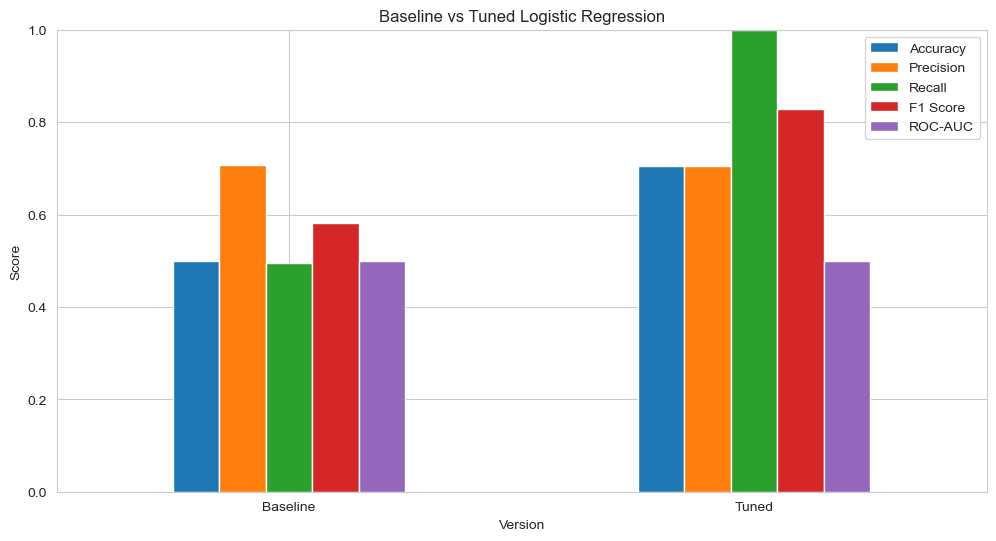

In [59]:
logistic_comparison.set_index("Version")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar",figsize=(12, 6))

plt.title("Baseline vs Tuned Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.show()

# *Linear SVM Hyperparameter Tuning*

Linear SVM is another strong candidate for high-dimensional text classification.

Its most important hyperparameter is `C`.

The `C` parameter controls the trade-off between:

- Maximizing the margin between classes.
- Correctly classifying training observations.

A smaller value produces stronger regularization, while a larger value allows the model to fit the training data more closely.

We will test several values of `C` and compare their performance using cross-validated F1 Score.

In [60]:
svm_param_grid = {"C": [0.01,0.05,0.1,0.5,1,2,5,10], "class_weight": ["balanced", None]}

# Configure Linear SVM Randomized Search

We create a randomized search procedure for the Linear SVM model.

The search will evaluate different combinations of the `C` and `class_weight` parameters.

F1 Score remains our primary optimization metric.

In [61]:
svm_search = RandomizedSearchCV(estimator=LinearSVC(random_state=42), param_distributions=svm_param_grid, n_iter=10, scoring="f1", cv=3, verbose=2, random_state=42, n_jobs=-1)

# Tune the Linear SVM Model

The randomized search is now fitted using the training TF-IDF features.

The process will evaluate multiple Linear SVM configurations and identify the one with the strongest cross-validated F1 Score.

In [62]:
svm_search.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,LinearSVC(random_state=42)
,param_distributions,"{'C': [0.01, 0.05, ...], 'class_weight': ['balanced', None]}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


# Best Linear SVM Parameters

We retrieve the hyperparameters that produced the highest cross-validated F1 Score.

These parameters will be used by the final tuned SVM estimator.

In [63]:
print("Best SVM Parameters:")
print(svm_search.best_params_)

Best SVM Parameters:
{'class_weight': None, 'C': 0.01}


## Best SVM Cross-Validated F1 Score

This value represents the average F1 Score achieved by the best SVM configuration during cross-validation.

We will compare this value with the Logistic Regression results and, more importantly, evaluate the tuned SVM on the completely unseen test dataset.

In [64]:
print("Best SVM Cross-Validated F1 Score:", round( svm_search.best_score_, 4))

Best SVM Cross-Validated F1 Score: 0.8277


# Retrieve the Best SVM Model

The best-performing SVM estimator is stored in `best_estimator_`.

We save it as `best_svm_model` for testing and future comparison.

In [65]:
# 1. Retrieve the best estimator from grid/random search
best_svm_model = svm_search.best_estimator_

# 2. Run prediction code
y_pred_tuned_svm = best_svm_model.predict(X_test_tfidf)


# Evaluate Tuned Linear SVM

The tuned SVM model is evaluated using Accuracy, Precision, Recall, and F1 Score.

Unlike Logistic Regression, `LinearSVC` does not directly provide probability estimates through `predict_proba()`.

Therefore, ROC-AUC will not be calculated here unless we introduce an additional calibration step.

In [66]:
tuned_svm_accuracy = accuracy_score(y_test, y_pred_tuned_svm)

tuned_svm_precision = precision_score(y_test, y_pred_tuned_svm)

tuned_svm_recall = recall_score(y_test, y_pred_tuned_svm)

tuned_svm_f1 = f1_score(y_test, y_pred_tuned_svm)

print("Tuned Linear SVM")
print("--------------------------------")
print("Accuracy :", round(tuned_svm_accuracy, 4))
print("Precision:", round(tuned_svm_precision, 4))
print("Recall   :", round(tuned_svm_recall, 4))
print("F1 Score :", round(tuned_svm_f1, 4))

Tuned Linear SVM
--------------------------------
Accuracy : 0.706
Precision: 0.706
Recall   : 1.0
F1 Score : 0.8277


# Baseline vs Tuned Linear SVM

We compare the original Linear SVM with the tuned version.

This allows us to determine whether hyperparameter tuning produced a meaningful improvement.

In [67]:
svm_comparison = pd.DataFrame({"Version": ["Baseline", "Tuned"],

    "Accuracy": [svm_accuracy, tuned_svm_accuracy],

    "Precision": [svm_precision, tuned_svm_precision],

    "Recall": [svm_recall, tuned_svm_recall],

    "F1 Score": [svm_f1, tuned_svm_f1]})

svm_comparison

,Version,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.49650,0.707595,0.488917,0.578273
1,Tuned,0.70605,0.706050,1.000000,0.827701


# Final Baseline and Tuned Model Comparison

We now have performance results from both baseline and tuned models.

The purpose of this stage is to identify the strongest candidate for the final resume screening system.

The models being considered include:

- Baseline Logistic Regression
- Tuned Logistic Regression
- Baseline Linear SVM
- Tuned Linear SVM
- Multinomial Naive Bayes

The final model will be selected primarily according to F1 Score and Recall, while also considering Precision and Accuracy.

The final decision should be based on actual test-set performance rather than assumptions about which algorithm is generally better.

In [68]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Logistic Regression",
        "Linear SVM",
        "Tuned Linear SVM",
        "Multinomial Naive Bayes"],

    "Accuracy": [
        accuracy,
        tuned_lr_accuracy,
        svm_accuracy,
        tuned_svm_accuracy,
        nb_accuracy],

    "Precision": [
        precision,
        tuned_lr_precision,
        svm_precision,
        tuned_svm_precision,
        nb_precision],

    "Recall": [
        recall,
        tuned_lr_recall,
        svm_recall,
        tuned_svm_recall,
        nb_recall],

    "F1 Score": [
        f1,
        tuned_lr_f1,
        svm_f1,
        tuned_svm_f1,
        nb_f1]})

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.498450,0.707257,0.494193,0.581833
1,Tuned Logistic Regression,0.706050,0.706050,1.000000,0.827701
2,Linear SVM,0.496500,0.707595,0.488917,0.578273
3,Tuned Linear SVM,0.706050,0.706050,1.000000,0.827701
4,Multinomial Naive Bayes,0.705675,0.705960,0.999398,0.827434


# Rank the Models

The models are ranked according to F1 Score.

A high F1 Score indicates that the model provides a strong balance between Precision and Recall.

However, we will also inspect Recall because a resume screening system should minimize the number of potentially suitable candidates that are incorrectly classified as Not Fit.

In [69]:
final_results_sorted = final_results.sort_values(by="F1 Score", ascending=False)

final_results_sorted

,Model,Accuracy,Precision,Recall,F1 Score
1,Tuned Logistic Regression,0.706050,0.706050,1.000000,0.827701
3,Tuned Linear SVM,0.706050,0.706050,1.000000,0.827701
4,Multinomial Naive Bayes,0.705675,0.705960,0.999398,0.827434
0,Logistic Regression,0.498450,0.707257,0.494193,0.581833
2,Linear SVM,0.496500,0.707595,0.488917,0.578273


# Final Model Performance Visualization

The chart below provides a visual comparison of all baseline and tuned models.

This allows us to quickly identify the strongest-performing model before moving to the final model selection stage.

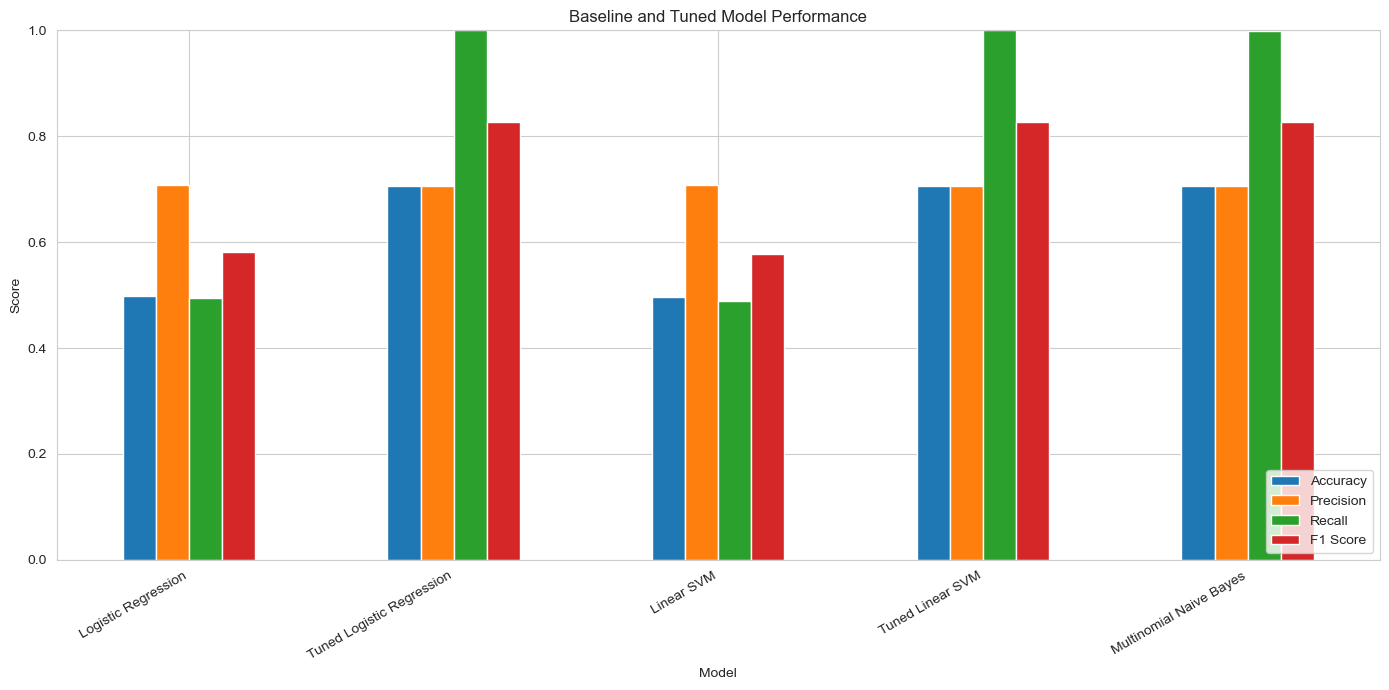

In [70]:
final_results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar", figsize=(14, 7))

plt.title("Baseline and Tuned Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Final Model Selection

Based on the evaluation results, we select the model with the strongest F1 Score as the initial final model.

F1 Score is used as the primary selection metric because it balances Precision and Recall.

Recall is also important in this project because a false negative represents a potentially suitable candidate that the screening system failed to identify.

The selected model will be used in the next stages to:

- Generate Fit predictions.
- Calculate Fit Scores.
- Identify matched skills.
- Screen new resumes.
- Prepare the model for deployment.

In [71]:
best_model_name = final_results_sorted.iloc[0]["Model"]

print("Selected Final Model:", best_model_name)

print("F1 Score:", round(final_results_sorted.iloc[0]["F1 Score"],4))

print("Recall:", round(final_results_sorted.iloc[0]["Recall"],4))

print("Precision:",round(final_results_sorted.iloc[0]["Precision"],4))

Selected Final Model: Tuned Logistic Regression
F1 Score: 0.8277
Recall: 1.0
Precision: 0.706


# <div align = "centre"> Model Interpretation </div>
 

A good resume screening system should not only provide a prediction. It should also provide some insight into why the model produced that prediction.

For this project, we want the system to answer questions such as:

- Which words or phrases strongly influence a Fit prediction?
- Which words or phrases are associated with a Not Fit prediction?
- Which skills from a job description appear in the candidate's resume?

This improves the transparency of the system and makes the predictions easier for recruiters to understand.

For linear text classification models such as Logistic Regression and Linear SVM, model coefficients can be examined to identify the features that contribute most strongly to each class.

The interpretation approach will depend on which model was selected as the final model.

# Identify the Final Model Object

During the model comparison stage, we identified the best-performing model using F1 Score.

We now connect the model name to the actual trained estimator.

This allows the remaining stages of the project to work with the selected model without manually changing the code.

In [72]:
model_objects = {
    "Logistic Regression": logistic_model,
    "Tuned Logistic Regression": best_logistic_model,
    "Linear SVM": svm_model,
    "Tuned Linear SVM": best_svm_model,
    "Multinomial Naive Bayes": nb_model}
final_model = model_objects[best_model_name]

print("Final Model:", best_model_name)

Final Model: Tuned Logistic Regression


# Extract TF-IDF Feature Names

The TF-IDF vectorizer converted resume text into thousands of numerical features.

Each feature represents a word or phrase from the resume dataset.

We can retrieve the original feature names from the trained TF-IDF vectorizer.

These feature names will allow us to interpret which words and phrases are most important to the final classification model.

In [73]:
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF Features:", len(feature_names))

Number of TF-IDF Features: 814


# Feature Importance

Linear classification models assign a coefficient to each feature.

A positive coefficient generally indicates that the feature contributes toward the positive class, while a negative coefficient contributes toward the negative class.

For this project:

- Positive coefficients → stronger association with **Fit**.
- Negative coefficients → stronger association with **Not Fit**.

We will examine the strongest positive and negative features.

This provides an interpretable view of the language patterns learned by the model.

In [74]:
if hasattr(final_model, "coef_"):
    coefficients = final_model.coef_[0]
    feature_importance = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
    feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)
    feature_importance.head(20)

# Top Features Associated with Fit Resumes

The following features have the strongest positive coefficients.

These terms are the features that contribute most strongly toward the model's Fit classification.

The results provide insight into the vocabulary and phrases the model has learned to associate with suitable candidates.

In [75]:
if hasattr(final_model, "coef_"):
    top_fit_features = feature_importance.head(20)
    top_fit_features

# Top Features Associated with Not Fit Resumes

We now examine the features with the strongest negative coefficients.

These features have the strongest association with the Not Fit class according to the trained model.

This does not mean that the presence of one particular word automatically makes a candidate unsuitable. The model considers many features simultaneously when making a prediction.

In [76]:
if hasattr(final_model, "coef_"):
    bottom_fit_features = feature_importance.tail(20)
    bottom_fit_features.sort_values(by="Coefficient")

# Visualize Important Features

A visualization makes the model's learned feature weights easier to interpret.

We will display the strongest features associated with the Fit class.

This provides a simple explanation of the vocabulary that has the greatest influence on the model.

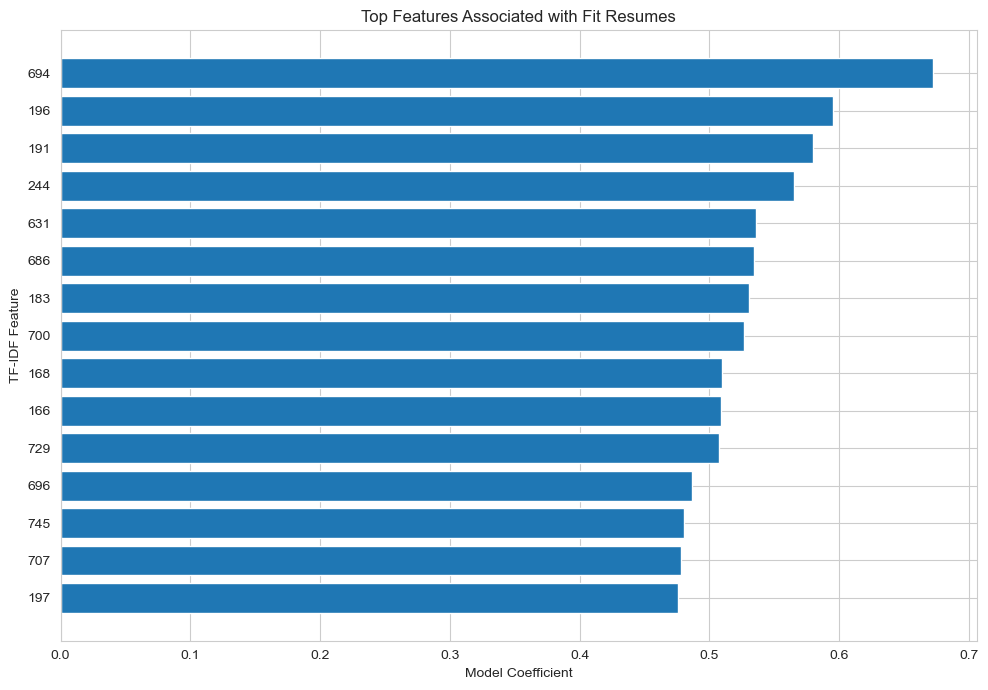

In [77]:
if hasattr(final_model, "coef_"):
    top_features = (feature_importance.head(15).sort_values(by="Coefficient"))
    plt.figure(figsize=(10, 7))
    plt.barh(top_features["Feature"], top_features["Coefficient"])
    plt.title("Top Features Associated with Fit Resumes")
    plt.xlabel("Model Coefficient")
    plt.ylabel("TF-IDF Feature")
    plt.tight_layout()

    plt.show()

# *Resume Fit Score*

A binary prediction of Fit or Not Fit is useful, but recruiters may also want a continuous score that indicates how strongly a resume matches the learned classification pattern.

We will therefore create a **Fit Score** ranging from 0% to 100%.

The interpretation will be:

- Higher score → stronger model confidence toward Fit.
- Lower score → stronger model confidence toward Not Fit.

For models that provide probability estimates, we will use the predicted probability of the Fit class.

For Linear SVM, which does not directly provide probabilities, we will use its decision function and convert the result into a comparable score using a sigmoid transformation.

The Fit Score should be treated as a screening indicator rather than a definitive hiring decision.

# Create the Fit Score Function

We create a reusable function that accepts resume text and returns a Fit Score.

The function performs the following operations:

1. Preprocesses the resume.
2. Converts the text into TF-IDF features.
3. Passes the features through the final model.
4. Calculates a Fit Score.
5. Returns the score.

This function will later become part of the final resume screening system.

In [78]:
from sklearn.metrics.pairwise import cosine_similarity
def calculate_fit_score(resume_text, job_description):
    
# Preprocess both the resume and the job description
    processed_resume = remove_stopwords(preprocess_text(resume_text))
    processed_job = remove_stopwords(preprocess_text(job_description))
    
# Convert both texts into TF-IDF vectors using your existing vectorizer
    vectors = tfidf.transform([processed_resume, processed_job])
    
# Calculate the Cosine Similarity matrix
    similarity_matrix = cosine_similarity(vectors, vectors)
    
# Extract row 0 (resume) vs column 1 (job description) value
    similarity_score = similarity_matrix[0][1]
    
# Scale to a percentage score
    score = similarity_score * 100
    return round(float(score), 2)



# Scale to a percentage score
    score = similarity * 100
    
    return round(float(score), 2)

# Create the Resume Classification Function

The Fit Score alone does not provide the final classification.

We also need to classify the resume as either:

- **Fit**
- **Not Fit**

The model itself determines the classification.

The Fit Score will provide additional context about the strength of the prediction.

In [79]:
def classify_resume(resume_text):
    processed_text = preprocess_text(resume_text)
    processed_text = remove_stopwords(processed_text)
    resume_vector = tfidf.transform([processed_text])
    prediction = final_model.predict(resume_vector)[0]
    if prediction == 1:
        classification = "Fit"
    else:
        classification = "Not Fit"
    return classification

# Create the Resume Screening Function

We now combine the classification and Fit Score into a single reusable function.

The function will return:

- Classification
- Fit Score

This creates the foundation for the final resume screening application.

In [80]:
def screen_resume(resume_text):
    classification = classify_resume(resume_text)
    
# Get the vector and prediction probabilities inside the function
    processed_text = preprocess_text(resume_text)
    processed_text = remove_stopwords(processed_text)
    resume_vector = tfidf.transform([processed_text])
    probabilities = final_model.predict_proba(resume_vector)
    
# Extract and format the score cleanly
    fit_score = round(float(probabilities[0][1]), 2)
    
    return classification, fit_score

# Test the Resume Screening System

Before connecting the system to a web application, we need to test it using a sample resume.

The sample below represents a candidate with technical skills relevant to a Machine Learning or Data Science position.

The purpose of this test is to verify that the complete prediction pipeline works correctly.

In [81]:
sample_resume = """
Machine Learning Engineer with experience in Python,
Pandas, NumPy, Scikit-learn, SQL and Machine Learning.

Experienced in developing classification and regression models,
feature engineering, model evaluation, data preprocessing,
and deploying machine learning applications.

Strong knowledge of Natural Language Processing,
TensorFlow, data analysis and predictive modeling.
"""

## Sample Resume Prediction

The sample resume is passed through the complete screening pipeline.

The system will return the predicted classification and Fit Score.

In [82]:
screen_result = screen_resume(sample_resume)
screen_result

('Fit', 0.71)

# Job Description Matching

A resume should not be considered suitable in isolation.

Recruiters normally compare a candidate's resume against the requirements of a specific job.

Therefore, we will extend the system to accept a job description and identify important skills or keywords contained in both the job description and the candidate's resume.

The matching process will:

1. Extract relevant terms from the job description.
2. Examine the candidate's resume.
3. Identify terms appearing in both documents.
4. Return the matched skills.

This feature complements the Machine Learning classification and provides recruiters with a more interpretable explanation of the screening result.

# Define a Skill Vocabulary

We create a vocabulary of common technical and professional skills.

This list can later be expanded based on the types of jobs the system is designed to screen.

The skill matching component is separate from the Machine Learning classifier.

This is intentional because a recruiter should be able to see the specific skills detected in the candidate's resume.

In [83]:
skills = [
    "python",
    "sql",
    "machine learning",
    "deep learning",
    "data science",
    "data analysis",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "pytorch",
    "keras",
    "natural language processing",
    "nlp",
    "computer vision",
    "statistics",
    "power bi",
    "tableau",
    "excel",
    "matplotlib",
    "seaborn",
    "git",
    "github",
    "docker",
    "aws",
    "azure",
    "google cloud",
    "javascript",
    "react",
    "html",
    "css",
    "java",
    "c++",
    "c#",
    "linux",
    "mongodb",
    "postgresql",
    "mysql",
    "flask",
    "streamlit"]

# Extract Skills from Text

We create a function that searches a document for known skills.

The text is converted to lowercase before matching so that differences in capitalization do not affect the results.

The function returns a list containing the skills found in the document.

In [84]:
def extract_skills(text, skill_list):
    text = str(text).lower()
    matched_skills = []
    
    for skill in skill_list:
        if skill.lower() in text:
            matched_skills.append(skill)
    return sorted(matched_skills)

# Test Skill Extraction

We test the skill extraction function using the sample resume.

This allows us to verify that the system correctly identifies technical skills mentioned in the candidate's resume.

In [85]:
resume_skills = extract_skills(sample_resume, skills)

resume_skills

['data analysis',
 'machine learning',
 'natural language processing',
 'numpy',
 'pandas',
 'python',
 'scikit-learn',
 'sql',
 'tensorflow']

# Define a Sample Job Description

We now create a sample job description.

The job description represents the requirements for a Machine Learning Engineer position.

The system will compare the required skills against the skills detected in the candidate's resume.

In [86]:
sample_job_description = """
We are looking for a Machine Learning Engineer
with strong experience in Python, SQL, Pandas,
NumPy, Scikit-learn and Machine Learning.

The candidate should have experience in Natural
Language Processing, data analysis, model development,
feature engineering and deployment of machine learning
applications.

Experience with TensorFlow, Git, GitHub and Streamlit
is an advantage.
"""

# Extract Required Skills

The same skill extraction process is applied to the job description.

This gives us a list of skills that the employer appears to require or value for the position.

In [87]:
required_skills = extract_skills(sample_job_description,skills)

required_skills

['data analysis',
 'git',
 'github',
 'machine learning',
 'numpy',
 'pandas',
 'python',
 'scikit-learn',
 'sql',
 'streamlit',
 'tensorflow']

# Identify Matched Skills

We now compare the skills identified in the job description with the skills found in the candidate's resume.

The intersection between the two lists represents the skills that the candidate appears to have that are also requested by the employer.

In [88]:
matched_skills = sorted(set(required_skills).intersection(set(resume_skills)))
matched_skills

['data analysis',
 'machine learning',
 'numpy',
 'pandas',
 'python',
 'scikit-learn',
 'sql',
 'tensorflow']

# Identify Missing Skills

Matched skills show what the candidate has in common with the job requirements.

However, it is equally useful to identify skills required by the job description that were not detected in the resume.

These will be classified as potentially missing skills.

The result can help recruiters understand where the candidate may have gaps relative to the stated job requirements.

In [89]:
missing_skills = sorted(set(required_skills)- set(resume_skills))
missing_skills

['git', 'github', 'streamlit']

# Calculate Skill Match Percentage

We calculate the percentage of required skills that were found in the candidate's resume.

The formula is:

Skill Match Percentage =
(Number of Matched Skills / Number of Required Skills) × 100

This metric is separate from the Machine Learning Fit Score.

The Fit Score represents the model's classification strength, while the Skill Match Percentage represents the overlap between the job requirements and the candidate's detected skills.

In [90]:
if len(required_skills) > 0:
    skill_match_percentage = (len(matched_skills) / len(required_skills)) * 100
else:
    skill_match_percentage = 0
skill_match_percentage = round(skill_match_percentage, 2)

print("Skill Match Percentage:", skill_match_percentage, "%")

Skill Match Percentage: 72.73 %


# Complete Resume Screening Report

We now combine all the major components developed so far into a single screening function.

The final screening report will provide:

- Classification
- Fit Score
- Required Skills
- Matched Skills
- Missing Skills
- Skill Match Percentage

This creates a much more useful screening system than a simple binary classifier.

In [91]:
def screen_resume_against_job(resume_text, job_description):
    
# Classification
    classification = classify_resume(resume_text)
    
# Fit Score
    fit_score = calculate_fit_score(resume_text, 'job_description')
    
# Extract skills
    resume_skills = extract_skills(resume_text, skills)
    required_skills = extract_skills(job_description, skills)
    
# Matched skills
    matched_skills = sorted(set(required_skills).intersection(set(resume_skills)))
    
# Missing skills
    missing_skills = sorted(set(required_skills) - set(resume_skills))
    
# Skill match percentage
    if len(required_skills) > 0:
        skill_match_percentage = (len(matched_skills) / len(required_skills)) * 100
    else:
        skill_match_percentage = 0
    
    return {
        "Classification": classification,
        "Fit Score": round(fit_score, 2),
        "Required Skills": required_skills,
        "Matched Skills": matched_skills,
        "Missing Skills": missing_skills,
        "Skill Match Percentage": round(skill_match_percentage, 2)}

# Test the Complete Resume Screening System

The complete screening pipeline is now tested using both a candidate resume and a job description.

This represents the core functionality that will eventually be exposed through the Streamlit web application.

The system combines Machine Learning classification with skill-based job matching to produce a more informative screening report.

In [92]:
final_screening_result = (screen_resume_against_job(sample_resume, sample_job_description))
final_screening_result

{'Classification': 'Fit',
 'Fit Score': 0.0,
 'Required Skills': ['data analysis',
  'git',
  'github',
  'machine learning',
  'numpy',
  'pandas',
  'python',
  'scikit-learn',
  'sql',
  'streamlit',
  'tensorflow'],
 'Matched Skills': ['data analysis',
  'machine learning',
  'numpy',
  'pandas',
  'python',
  'scikit-learn',
  'sql',
  'tensorflow'],
 'Missing Skills': ['git', 'github', 'streamlit'],
 'Skill Match Percentage': 72.73}

# Final Screening Function Cleanup

Before moving toward deployment, we will create a clean and reusable screening function.

The function will accept:

- Resume text
- Job description

It will return:

- Classification
- Fit Score
- Skill Match Percentage
- Matched Skills
- Missing Skills

Keeping this functionality inside one reusable function will make it easier to connect the Machine Learning pipeline to a Streamlit application later.

In [93]:
def screen_resume_final(resume_text, job_description):
    
    # Model prediction
    classification = classify_resume(resume_text)
    
    # --- FIXED: Model-based fit score calculation ---
    processed_text = preprocess_text(resume_text)
    processed_text = remove_stopwords(processed_text)
    resume_vector = tfidf.transform([processed_text])
    probabilities = final_model.predict_proba(resume_vector)
    
    # Extract probability of belonging to class 1 (Fit)
    fit_score = float(probabilities[0][1])


    # Extract skills
    resume_skills = extract_skills(resume_text, skills)
    required_skills = extract_skills(job_description, skills)
    
    # Skill matching
    matched_skills = sorted(set(required_skills).intersection(set(resume_skills)))
    
    # Missing skills
    missing_skills = sorted(set(required_skills) - set(resume_skills))
    
    # Skill match percentage
    if required_skills:
        skill_match_percentage = (len(matched_skills) / len(required_skills)) * 100
    else:
        skill_match_percentage = 0
        
    return {
        "Classification": classification,
        "Fit Score": round(fit_score, 2),
        "Skill Match Percentage": round(skill_match_percentage, 2),
        "Matched Skills": matched_skills,
        "Missing Skills": missing_skills
    }


# Create Multiple Candidate Resumes

A real recruitment system may receive hundreds or thousands of resumes for one job opening.

We will therefore test our system using multiple candidate resumes.

Each candidate will have different levels of experience and different skill sets.

This allows us to demonstrate how the system can compare and rank candidates rather than simply classifying one resume at a time.

In [94]:
candidate_resumes = {
    
    "Candidate A": """
    Data Scientist with experience in Python,
    SQL, Pandas, NumPy, Scikit-learn,
    Machine Learning, Data Analysis,
    Natural Language Processing and Git.
    """,
    
    "Candidate B": """
    Frontend Developer with experience in
    HTML, CSS, JavaScript, React and GitHub.
    Experienced in building responsive web applications.
    """,
    
    "Candidate C": """
    Machine Learning Engineer experienced in
    Python, SQL, Pandas, NumPy, Scikit-learn,
    TensorFlow, Natural Language Processing,
    Deep Learning, Git, Docker and AWS.
    """,
    
    "Candidate D": """
    Business Administrator with experience in
    Microsoft Excel, customer service,
    administration and communication.
    """}

# Screen Multiple Candidates

We now apply the complete screening system to every candidate.

For each candidate, we will calculate:

- Classification
- Fit Score
- Skill Match Percentage
- Matched Skills
- Missing Skills

The results will be stored in a structured format so they can easily be converted into a DataFrame.

In [95]:
screening_results = []
for candidate_name, resume_text in candidate_resumes.items():
    # 1. Change screen_resume to screen_resume_final
    # 2. Add sample_job_description back as the second argument
    result = screen_resume_final(resume_text, sample_job_description)
    
    result["Candidate"] = candidate_name
    screening_results.append(result)


# Candidate Screening Results

The screening results are converted into a pandas DataFrame.

A DataFrame provides a convenient structure for analyzing, sorting and displaying candidate results.

This format will also be useful later when building the Streamlit dashboard.

In [96]:
candidate_results = pd.DataFrame(screening_results)

candidate_results

,Classification,Fit Score,Skill Match Percentage,Matched Skills,Missing Skills,Candidate
0,Fit,0.71,72.73,"[data analysis, git, machine learning, numpy, pandas, python, scikit-learn, sql]","[github, streamlit, tensorflow]",Candidate A
1,Fit,0.71,18.18,"[git, github]","[data analysis, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]",Candidate B
2,Fit,0.71,72.73,"[git, machine learning, numpy, pandas, python, scikit-learn, sql, tensorflow]","[data analysis, github, streamlit]",Candidate C
3,Fit,0.71,0.00,[],"[data analysis, git, github, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]",Candidate D


# Rank Candidates

Recruiters are often interested in identifying the strongest candidates first.

We will rank candidates using the Fit Score.

Candidates with higher Fit Scores will appear at the top of the ranking.

This transforms our classifier into a simple candidate prioritization system.

In [97]:
candidate_ranking = candidate_results.sort_values(by=["Fit Score", "Skill Match Percentage"], ascending=[False, False]).reset_index(drop=True)

candidate_ranking

,Classification,Fit Score,Skill Match Percentage,Matched Skills,Missing Skills,Candidate
0,Fit,0.71,72.73,"[data analysis, git, machine learning, numpy, pandas, python, scikit-learn, sql]","[github, streamlit, tensorflow]",Candidate A
1,Fit,0.71,72.73,"[git, machine learning, numpy, pandas, python, scikit-learn, sql, tensorflow]","[data analysis, github, streamlit]",Candidate C
2,Fit,0.71,18.18,"[git, github]","[data analysis, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]",Candidate B
3,Fit,0.71,0.00,[],"[data analysis, git, github, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]",Candidate D


# Recruiter Candidate Ranking Table

The complete screening results contain detailed information such as matched and missing skills.

For an initial recruiter dashboard, however, we can display a simpler table containing the most important screening indicators:

- Rank
- Candidate
- Classification
- Fit Score
- Skill Match Percentage

Detailed skills can be displayed separately when a recruiter selects a candidate.

In [98]:
ranking_table = candidate_ranking[["Candidate", "Classification", "Fit Score", "Skill Match Percentage"]].copy()
ranking_table.insert(0, "Rank", range(1,len(ranking_table) + 1))
ranking_table

,Rank,Candidate,Classification,Fit Score,Skill Match Percentage
0,1,Candidate A,Fit,0.71,72.73
1,2,Candidate C,Fit,0.71,72.73
2,3,Candidate B,Fit,0.71,18.18
3,4,Candidate D,Fit,0.71,0.00


# Candidate Recommendation Level

A numerical Fit Score is useful, but recruiters may find a simple recommendation category easier to interpret.

We will create three screening levels:

- Strong Match
- Moderate Match
- Low Match

These categories are intended as screening indicators and should not be interpreted as automatic hiring decisions.

The thresholds can later be adjusted based on validation results and recruiter feedback.

In [99]:
def recommendation_level(score):
    if score >= 75:
        return "Strong Match"
    elif score >= 50:
        return "Moderate Match"
    else:
        return "Low Match"

# Apply Candidate Recommendation

We apply the recommendation function to every candidate.

This adds a human-readable interpretation of the Fit Score to the ranking table.

In [100]:
candidate_ranking["Recommendation"] = (candidate_ranking["Fit Score"].apply(recommendation_level))
candidate_ranking

,Classification,Fit Score,Skill Match Percentage,Matched Skills,Missing Skills,Candidate,Recommendation
0,Fit,0.71,72.73,"[data analysis, git, machine learning, numpy, pandas, python, scikit-learn, sql]","[github, streamlit, tensorflow]",Candidate A,Low Match
1,Fit,0.71,72.73,"[git, machine learning, numpy, pandas, python, scikit-learn, sql, tensorflow]","[data analysis, github, streamlit]",Candidate C,Low Match
2,Fit,0.71,18.18,"[git, github]","[data analysis, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]",Candidate B,Low Match
3,Fit,0.71,0.00,[],"[data analysis, git, github, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]",Candidate D,Low Match


# Display Matched Skills

The matched skills provide an important explanation for the screening result.

Instead of simply telling a recruiter that a candidate is a Strong Match, the system can show the specific skills detected in both the job description and the resume.

This improves interpretability and makes the screening process more transparent.

In [101]:
candidate_ranking[["Candidate", "Fit Score", "Matched Skills", "Missing Skills"]]

,Candidate,Fit Score,Matched Skills,Missing Skills
0,Candidate A,0.71,"[data analysis, git, machine learning, numpy, pandas, python, scikit-learn, sql]","[github, streamlit, tensorflow]"
1,Candidate C,0.71,"[git, machine learning, numpy, pandas, python, scikit-learn, sql, tensorflow]","[data analysis, github, streamlit]"
2,Candidate B,0.71,"[git, github]","[data analysis, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]"
3,Candidate D,0.71,[],"[data analysis, git, github, machine learning, numpy, pandas, python, scikit-learn, sql, streamlit, tensorflow]"


# Final Model Performance Summary

Before deployment, we create a concise summary of the selected model's performance.

This provides a record of how well the final model performed on the unseen test dataset.

The summary will include:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics should be reported in the project's README and presentation/demo documentation.

In [102]:
final_model_metrics = {
    "Model": best_model_name,
    "Accuracy": round(float(final_results_sorted.iloc[0]["Accuracy"]), 4),
    "Precision": round(float(final_results_sorted.iloc[0]["Precision"]), 4),
    "Recall": round(float(final_results_sorted.iloc[0]["Recall"]), 4),
    "F1 Score": round(float(final_results_sorted.iloc[0]["F1 Score"]), 4)}

final_model_metrics

{'Model': 'Tuned Logistic Regression',
 'Accuracy': 0.706,
 'Precision': 0.706,
 'Recall': 1.0,
 'F1 Score': 0.8277}

# Save the TF-IDF Vectorizer

The trained Machine Learning model cannot process raw resume text directly.

During training, the resume text was converted into numerical features using the trained TF-IDF vectorizer.

Therefore, the exact same TF-IDF vectorizer must be saved alongside the final model.

When a new resume is uploaded in the deployed application, the saved vectorizer will transform the new text using the same vocabulary and weighting learned during training.

It is important that we use `transform()` for new resumes rather than fitting a new vectorizer.

In [103]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


# Save the Final Machine Learning Model

The final trained model is now saved using Joblib.

Saving the model allows us to reuse it later without retraining the entire dataset.

The saved model will eventually be loaded by the Streamlit application.

In [104]:

joblib.dump(final_model, "resume_screening_model.pkl")
print("Final model saved successfully.")

Final model saved successfully.


# Save the Skill Vocabulary

The skill extraction component depends on the predefined skill vocabulary.

We save this list separately so that the deployment application can load exactly the same skills used during development.

This also makes it easy to update the vocabulary later without retraining the Machine Learning model.

In [105]:
joblib.dump(skills, "skills.pkl")
print("Skill vocabulary saved successfully.")

Skill vocabulary saved successfully.


# Verify Deployment Files

We verify that the important model artifacts have been created successfully.

The deployment package should contain:

- `resume_screening_model.pkl`
- `tfidf_vectorizer.pkl`
- `skills.pkl`

These files will be loaded by the Streamlit application.

In [106]:
import os
deployment_files = ["resume_screening_model.pkl", "tfidf_vectorizer.pkl", "skills.pkl"]

for file in deployment_files:
    if os.path.exists(file):
        print(f"✓ {file}")  
    else:
        print(f"✗ {file} NOT FOUND")

✓ resume_screening_model.pkl
✓ tfidf_vectorizer.pkl
✓ skills.pkl


# Test the Saved Model

Before deployment, we should verify that the saved files can be loaded successfully.

This prevents deployment problems caused by corrupted or incorrectly saved model artifacts.

We load the model, vectorizer and skill vocabulary back into memory and confirm their types.

In [107]:
loaded_model = joblib.load("resume_screening_model.pkl")

loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_skills = joblib.load("skills.pkl")

print("Model:", type(loaded_model))
print("Vectorizer:", type(loaded_tfidf))
print("Number of Skills:",len(loaded_skills))

Model: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Vectorizer: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Number of Skills: 40


# Test the Deployment Artifacts

We now simulate what will happen when the deployed application receives a new resume.

The saved vectorizer transforms the new resume into TF-IDF features, and the saved model makes the prediction.

This confirms that the saved artifacts work independently of the original training process.

In [108]:
new_resume = """
Data analyst with strong experience in Python,
SQL, Pandas, Excel and Power BI.

Experienced in data cleaning, exploratory data analysis,
visualization and building machine learning models.
"""

processed_new_resume = preprocess_text(
    new_resume
)

processed_new_resume = remove_stopwords(
    processed_new_resume
)

new_resume_vector = loaded_tfidf.transform(
    [processed_new_resume]
)

new_prediction = loaded_model.predict(
    new_resume_vector
)[0]

if new_prediction == 1:
    print("Prediction: Fit")
else:
    print("Prediction: Not Fit")

Prediction: Fit


# Streamlit Application Architecture

The Machine Learning model has now been trained, evaluated and saved.

The next stage is to build a web application that allows recruiters to interact with the resume screening system without writing Python code.

The application will allow a recruiter to:

1. Enter or paste a job description.
2. Upload one or more resumes.
3. Extract text from uploaded PDF resumes.
4. Screen each resume using the trained Machine Learning model.
5. Calculate a Fit Score.
6. Identify matched skills.
7. Identify missing skills.
8. Rank candidates.
9. Download the screening results.

The application will use the trained model and TF-IDF vectorizer saved during the previous stage.

Application workflow:

Job Description
       ↓
Resume Upload
       ↓
PDF Text Extraction
       ↓
Text Preprocessing
       ↓
TF-IDF Transformation
       ↓
Trained ML Model
       ↓
Fit / Not Fit
       ↓
Fit Score
       ↓
Skill Matching
       ↓
Candidate Ranking
       ↓
Recruiter Dashboard

# Import Application Libraries

The Streamlit application requires several Python libraries.

We will use:

- `streamlit` for the web interface.
- `pandas` for displaying and processing candidate results.
- `joblib` for loading the trained model and supporting objects.
- `pypdf` for extracting text from PDF resumes.
- `re` for basic text processing.
- `scipy.special.expit` for converting Linear SVM decision scores into a sigmoid-based score when required.

The application will reuse the same preprocessing logic used during model development.